Optimized Kernel: 0.773**2 * RBF(length_scale=1.49)


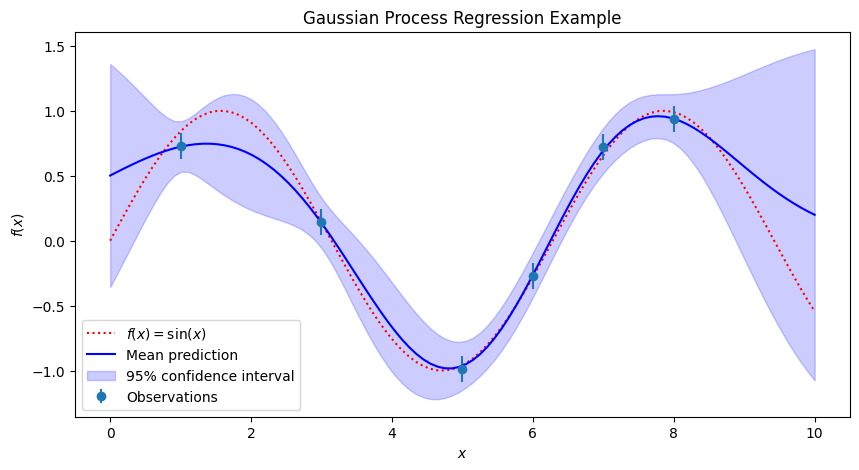

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# --- 1. Generate Training Data ---
# Training inputs X_train (must be 2D array for scikit-learn)
X_train = np.array([1., 3., 5., 6., 7., 8.]).reshape(-1, 1)
# Training targets y_train
y_train = (np.sin(X_train)).ravel() + np.random.normal(0, 0.1, X_train.shape[0])

# --- 2. Define the Kernel ---
# We use a Radial Basis Function (RBF) kernel with an amplitude factor (C)
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# --- 3. Initialize and Fit the GP Regressor ---
# `alpha` specifies the noise level (variance of the observation noise)
# `n_restarts_optimizer` tries to find better kernel hyperparameters
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.1**2,  # Assuming a noise standard deviation of 0.1
    n_restarts_optimizer=10
)

# Fit the GP to the training data
gp.fit(X_train, y_train)

print(f"Optimized Kernel: {gp.kernel_}")

# --- 4. Generate Test Data and Predict ---
# Test points for prediction
X_test = np.linspace(0, 10, 100).reshape(-1, 1)

# Predict mean and standard deviation (return_std=True)
y_mean, y_std = gp.predict(X_test, return_std=True)

# --- 5. Plotting Results ---
plt.figure(figsize=(10, 5))
plt.plot(X_test, np.sin(X_test), 'r:', label=r'$f(x) = \sin(x)$')  # True function
plt.errorbar(X_train.ravel(), y_train, 0.1, fmt='o', label='Observations')
plt.plot(X_test, y_mean, 'b-', label='Mean prediction')
plt.fill_between(
    X_test.ravel(),
    y_mean - 1.96 * y_std,
    y_mean + 1.96 * y_std,
    alpha=0.2,
    color='b',
    label='95% confidence interval'
)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend(loc='lower left')
plt.title('Gaussian Process Regression Example')
plt.show()

In [324]:
import torch 
import gpytorch
from core.GaussianProcessModule import GaussianProcessModule 
from matplotlib import pyplot as plt
def log_model_parameters(model):
    total_params = 0
    total_trainable = 0

    print("===== Model Parameters =====")
    for name, param in model.named_parameters():
        num_params = param.numel()
        total_params += num_params
        if param.requires_grad:
            total_trainable += num_params
        print(f"{name}: {param.size()} | params={num_params} | requires_grad={param.requires_grad}")

    print(f"Total parameters: {total_params}")
    print(f"Trainable parameters: {total_trainable}")
    print("============================")

In [24]:

class TestNN(torch.nn.Module) :
    def __init__(self, dim: int, a1: gpytorch.models.ExactGP, a2: gpytorch.models.ExactGP) :
        super().__init__()
        self.dim = dim
        self.a1 = a1
        self.a2 = a2
    def forward(self, x) :
        return 0.5 * self.a1(x) + 0.3 * self.a2(x)

In [25]:

if __name__ == "__main__" :
    train_x = torch.linspace(0, 1, 100)
    training_iter = 1000
    # True function is sin(2*pi*x) with Gaussian noise
    train_y = torch.sin(train_x * (2 * torch.pi)) + torch.randn(train_x.size()) * 0.144 ** 0.5
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    # a1 = GaussianProcessModule(alpha_size = 1, beta_size = 2, s0 = torch.tensor([3, 3]).T, dim = 2)
    # a2 = GaussianProcessModule(alpha_size = 1, beta_size = 2, s0 = torch.tensor([3, 3]).T, dim = 2)
    g = GaussianProcessModule(train_x = train_x, train_y = train_y, likelihood=likelihood, alpha_size = 1, beta_size = 1, s0 = torch.tensor(1), dim = 1)
    h = GaussianProcessModule(train_x = train_x, train_y = train_y, likelihood=likelihood, alpha_size = 1, beta_size = 1, s0 = torch.tensor(2), dim = 1)
    # tau3GPs = KirchhoffStressNN(dim = 2, a1 = a1, a2 = a2, g = g)
    model = TestNN(1, g, h)
    model.train()
    likelihood.train()
    print(log_model_parameters(model))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.backward()
        print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
            i + 1, training_iter, loss.item(),
            g.covar_module.base_kernel.lengthscale.item(),
            g.likelihood.noise.item()
        ))
        optimizer.step()
    # print(tau3GPs.parameters())

    # Get into evaluation (predictive posterior) mode
    model.eval()
    likelihood.eval()

    # Test points are regularly spaced along [0,1]
    # Make predictions by feeding model through likelihood
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        test_x = torch.linspace(0, 1, 51)
        observed_pred = likelihood(model(test_x))

    with torch.no_grad():
        # Initialize plot
        f, ax = plt.subplots(1, 1, figsize=(4, 3))

        # Get upper and lower confidence bounds
        lower, upper = observed_pred.confidence_region()
        # Plot training data as black stars
        ax.plot(train_x.numpy(), train_y.numpy(), 'k*')
        # Plot predictive means as blue line
        ax.plot(test_x.numpy(), observed_pred.mean.numpy(), 'b')
        # Shade between the lower and upper confidence bounds
        ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
        ax.set_ylim([-3, 3])
        ax.legend(['Observed Data', 'Mean', 'Confidence'])
        plt.show()

===== Model Parameters =====
a1.likelihood.noise_covar.raw_noise: torch.Size([1]) | params=1 | requires_grad=True
a1.mean_module.alpha: torch.Size([1]) | params=1 | requires_grad=True
a1.mean_module.beta: torch.Size([1]) | params=1 | requires_grad=True
a1.covar_module.raw_outputscale: torch.Size([]) | params=1 | requires_grad=True
a1.covar_module.base_kernel.raw_lengthscale: torch.Size([1, 1]) | params=1 | requires_grad=True
a2.mean_module.alpha: torch.Size([1]) | params=1 | requires_grad=True
a2.mean_module.beta: torch.Size([1]) | params=1 | requires_grad=True
a2.covar_module.raw_outputscale: torch.Size([]) | params=1 | requires_grad=True
a2.covar_module.base_kernel.raw_lengthscale: torch.Size([1, 1]) | params=1 | requires_grad=True
Total parameters: 9
Trainable parameters: 9
None


RuntimeError: All MarginalLogLikelihood objects must be given a GP object as a model. If you are using a more complicated model involving a GP, pass the underlying GP object as the model, not a full PyTorch module.

In [10]:
g.mean_module.alpha

Parameter containing:
tensor([0.1313], requires_grad=True)

In [11]:
g.mean_module.beta

Parameter containing:
tensor([0.2558], requires_grad=True)

In [17]:
print(g.covar_module.base_kernel.lengthscale)

tensor([[0.2210]], grad_fn=<SoftplusBackward0>)


In [24]:
import gpytorch
import torch

In [25]:
class AffineMeanModule(gpytorch.means.Mean):
    def __init__(self, alpha_size: int, beta_size: int, s0: torch.Tensor):
        super().__init__()
        self.alpha = torch.nn.Parameter(torch.zeros(alpha_size))
        self.beta  = torch.nn.Parameter(torch.zeros(beta_size))
        self.s0 = s0

    def forward(self, s):

        return (self.alpha + self.beta.T * (s - self.s0.T)).squeeze(-1)
    
class GaussianProcessModule(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, alpha_size: int, beta_size: int, s0: torch.Tensor, dim: int):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = AffineMeanModule(alpha_size, beta_size, s0)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=dim)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [26]:
class KirchhoffStress3GPs(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, dim: int):
        super().__init__(train_x, train_y, likelihood)
        self.a1_mean_module = AffineMeanModule(1, 2, torch.tensor([3,3]).T)
        self.a1_covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=dim)
        )
        self.a2_mean_module = AffineMeanModule(1, 2, torch.tensor([3,3]).T)
        self.a2_covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=dim)
        )

        self.g_mean_module = AffineMeanModule(1, 1, torch.tensor(1))
        self.g_covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=dim)
        )
    def input_layer(self, deformation_gradient) :
        j = torch.det(deformation_gradient)
        F_bar = torch.pow(j, -1/3.0) * deformation_gradient
        B_bar = F_bar @ F_bar.T
        
        I1_bar = torch.trace(B_bar)
        I2_bar = 0.5 * (torch.trace(B_bar) ** 2 - torch.trace(B_bar @ B_bar))
        return (B_bar, j, I1_bar, I2_bar)
    def phi(self, T, deformation_gradient, gradu_x) :
        phi = torch.einsum('bij,bij->b', T @ torch.inverse(deformation_gradient).transpose(-1, -2), gradu_x)
        return phi
    def T1(self, B_bar) :
        return B_bar - torch.trace(B_bar)/3 * torch.eye(B_bar.shape[-1])
    def T2(self, B_bar) :
        return (torch.trace(B_bar) * torch.eye(B_bar.shape[-1]) - B_bar) - 2.0/3.0 * torch.trace(B_bar) * torch.eye(B_bar.shape[-1])
    def g_(self, j) :
        return (j - 1) * self.g(j)
    def forward(self, deformation_gradient, gradu_x):
        # input layer
        B_bar, j, I1_bar, I2_bar = self.input_layer(deformation_gradient)
        # mean_r = phi1 * mu1 + phi2 * mu2 + phiv * v - b
        # covar_r = phi1 * K1 * phi1.T + phi2 * K2 * phi2.T + phiv * Kv * phiv.T
        phi_1 = self.phi(self.T1(B_bar), deformation_gradient, gradu_x)
        phi_2 = self.phi(self.T2(B_bar), deformation_gradient, gradu_x)
        phi_v = self.phi(torch.eye(deformation_gradient.shape[-1], device = deformation_gradient.device ), deformation_gradient, gradu_x)
        mean_r = phi_1 * self.a1_mean_module(I1_bar, I2_bar) + phi_2 * self.a2_mean_module(I1_bar, I2_bar) + phi_v * self.g_mean_module(j)
        covar_r = phi_1 * self.a1_covar_module(I1_bar, I2_bar) * phi_1.T + phi_2 * self.a2_covar_module(I1_bar, I2_bar) * phi_2.T + phi_v * self.g_covar_module(j) * phi_v.T
        return gpytorch.distributions.MultivariateNormal(mean_r, covar_r)

In [ ]:
from core.datasetclass import BenchmarkDataset
import torch
data_dir = "/home/mmdiscovery/shared/dataset/benchmarks/"
noise = "noise=low"
mat_model = "NeoHookean"
dataset = BenchmarkDataset(data_dir, noise, mat_model)
data = dataset[10]
piola_stress = torch.tensor(data["piola_stress"])
qpWeight = torch.tensor(data["qpWeight"])
gradNa = data["gradNa"]
print(piola_stress.shape, gradNa.shape)

In [5]:
data_dir = "/home/mmdiscovery/shared/dataset/benchmarks/"
noise = "noise=low"
mat_model = "NeoHookean"
dataset = BenchmarkDataset(data_dir, noise, mat_model)
data = dataset[10]

In [6]:
voigtMap = [[0,1],[2,3]]
gradu_x = torch.zeros(data["cells"].shape[0], 4, dtype = torch.float64)
for a in range(3):
    for i in range(2):
        for j in range(2):
            gradu_x[:,voigtMap[i][j]] += data["u_a"][:, a, i] * data["gradNa"][:, a, j]

In [7]:
data.keys()

dict_keys(['deformation_gradient', 'u_a', 'qpWeight', 'gradNa', 'piola_stress', 'cells', 'X_a', 'bc'])

In [8]:
piola_stress = torch.tensor(data["piola_stress"])
qpWeight = torch.tensor(data["qpWeight"])
gradNa = data["gradNa"]
print(piola_stress.shape, gradNa.shape)

torch.Size([2752, 4]) torch.Size([2752, 3, 2])


/tmp/ipykernel_37739/3340087138.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  qpWeight = torch.tensor(data["qpWeight"])


Weakform is 

$$\int_{\Omega} \mathbf{P} : \nabla \mathbf{v}^a d\Omega = 0$$
$$\int_{\Omega} \mathbf{P}_{ij} \nabla_j N^a d\Omega = f_i^a$$

In [9]:
f_int_nodes = torch.zeros(1441, 2, dtype = torch.float64)
for a in range(3):
	for i in range(2):
		for j in range(2):
			force = piola_stress[:, voigtMap[i][j]] * gradNa[:, a, j] * qpWeight.squeeze(-1)
			# print((piola_stress[:,voigtMap[i][j]] * gradNa[:, a, j]).shape)
			# print(qpWeight.shape)
			# break
			f_int_nodes[:,i].index_add_(0,torch.tensor(data["cells"][:, a]), force)

In [ ]:
boolbc = data["bc"] != 0
f_int_nodes[boolbc] = 0

In [19]:
f_int_nodes[boolbc] = 0

In [22]:
f_int_nodes

tensor([[ 6.1306e-14,  0.0000e+00],
        [ 0.0000e+00,  3.3985e-14],
        [ 0.0000e+00,  0.0000e+00],
        ...,
        [-1.9583e-16, -3.0748e-16],
        [-2.4340e-15,  3.8814e-15],
        [ 1.9483e-15, -1.9620e-15]], dtype=torch.float64)

In [84]:
piola_stress[:,voigtMap[i][j]].shape

torch.Size([2752])

In [78]:
data["cells"].max()

1440

In [72]:
torch.tensor(data["cells"]).shape

torch.Size([2752, 3])

In [71]:
torch.tensor(data["cells"][a])

tensor([144, 441, 443])

In [53]:
qpWeight.shape

torch.Size([2752, 1])

In [27]:
train_x = data["deformation_gradient"]
train_y = torch.zeros(data["deformation_gradient"].shape[0], device = train_x.device)
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = KirchhoffStress3GPs(train_x, train_y, likelihood=likelihood, dim = 2)

/tmp/ipykernel_37739/523903237.py:4: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4413.)
  self.a1_mean_module = AffineMeanModule(1, 2, torch.tensor([3,3]).T)


In [28]:
log_model_parameters(model)

NameError: name 'log_model_parameters' is not defined

In [24]:
train_x.shape

torch.Size([2752, 4])

In [70]:
x = torch.ones(5, 3)
t = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=torch.float)
index = torch.tensor([0, 4, 2])
x.index_add_(0, index, t)
# x.index_add_(0, index, t, alpha=-1)

tensor([[ 2.,  3.,  4.],
        [ 1.,  1.,  1.],
        [ 8.,  9., 10.],
        [ 1.,  1.,  1.],
        [ 5.,  6.,  7.]])

In [29]:
model.train()
output = model(train_x, gradu_x)

ValueError: Expected the lengths of all arguments to be equal. Got lengths [1, 2] for args [[tensor([[ 1.0495, -0.0051, -0.0061,  1.0931],
        [ 1.0496, -0.0054, -0.0065,  1.0939],
        [ 1.0495, -0.0057, -0.0069,  1.0930],
        ...,
        [ 1.0425, -0.0301, -0.0379,  1.0998],
        [ 1.0474, -0.0334, -0.0368,  1.0991],
        [ 1.0427, -0.0342, -0.0381,  1.1050]], dtype=torch.float64)], [tensor([[ 1.0495, -0.0051, -0.0061,  1.0931],
        [ 1.0496, -0.0054, -0.0065,  1.0939],
        [ 1.0495, -0.0057, -0.0069,  1.0930],
        ...,
        [ 1.0425, -0.0301, -0.0379,  1.0998],
        [ 1.0474, -0.0334, -0.0368,  1.0991],
        [ 1.0427, -0.0342, -0.0381,  1.1050]], dtype=torch.float64), tensor([[ 0.0495, -0.0051, -0.0061,  0.0931],
        [ 0.0496, -0.0054, -0.0065,  0.0939],
        [ 0.0495, -0.0057, -0.0069,  0.0930],
        ...,
        [ 0.0425, -0.0301, -0.0379,  0.0998],
        [ 0.0474, -0.0334, -0.0368,  0.0991],
        [ 0.0427, -0.0342, -0.0381,  0

In [30]:
class ScalarGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


In [31]:
class MixedGP(torch.nn.Module):
    def __init__(self, gp1, gp2, a1=0.5, a2=0.5):
        super().__init__()
        self.gp1 = gp1
        self.gp2 = gp2
        # optional: make weights learnable
        self.a1 = torch.nn.Parameter(torch.tensor(a1))
        self.a2 = torch.nn.Parameter(torch.tensor(a2))

    def forward(self, x):
        # Get predictions (MultivariateNormal)
        pred1 = self.gp1(x)
        pred2 = self.gp2(x)

        # Combine means
        mean_mix = self.a1 * pred1.mean + self.a2 * pred2.mean

        # Combine variances (assuming independent GPs)
        cov_mix = (self.a1 ** 2) * pred1.covariance_matrix + \
                  (self.a2 ** 2) * pred2.covariance_matrix

        return gpytorch.distributions.MultivariateNormal(mean_mix, cov_mix)


In [33]:
# Sample data
train_x = torch.linspace(0, 1, 20)
train_y = torch.sin(train_x * (2 * torch.pi)) + 0.1 * torch.randn(train_x.size())

# Likelihoods
lik1 = gpytorch.likelihoods.GaussianLikelihood()
lik2 = gpytorch.likelihoods.GaussianLikelihood()

# Two GPs
gp1 = ScalarGP(train_x, train_y, lik1)
gp2 = ScalarGP(train_x, train_y, lik2)

# Mixture
mix_gp = MixedGP(gp1, gp2)

# Optimizer
optimizer = torch.optim.Adam(mix_gp.parameters(), lr=0.1)

# Marginal log-likelihood
mll1 = gpytorch.mlls.ExactMarginalLogLikelihood(lik1, gp1)
mll2 = gpytorch.mlls.ExactMarginalLogLikelihood(lik2, gp2)
mix_gp.train()
lik1.train()
lik2.train()

for i in range(200):
    optimizer.zero_grad()
    output1 = gp1(train_x)
    output2 = gp2(train_x)

    # total loss = sum of individual GP losses
    loss = -mll1(output1, train_y) - mll2(output2, train_y)
    loss.backward()
    optimizer.step()

    if i % 20 == 0:
        print(f"Iter {i:3d} - Loss: {loss.item():.3f}, "
              f"a1: {mix_gp.a1.item():.3f}, a2: {mix_gp.a2.item():.3f}")


Iter   0 - Loss: 2.114, a1: 0.500, a2: 0.500
Iter  20 - Loss: 0.746, a1: 0.500, a2: 0.500
Iter  40 - Loss: -0.299, a1: 0.500, a2: 0.500
Iter  60 - Loss: -0.393, a1: 0.500, a2: 0.500
Iter  80 - Loss: -0.416, a1: 0.500, a2: 0.500
Iter 100 - Loss: -0.418, a1: 0.500, a2: 0.500
Iter 120 - Loss: -0.418, a1: 0.500, a2: 0.500
Iter 140 - Loss: -0.418, a1: 0.500, a2: 0.500
Iter 160 - Loss: -0.418, a1: 0.500, a2: 0.500
Iter 180 - Loss: -0.418, a1: 0.500, a2: 0.500


In [43]:
f = torch.randn(20)
likelihood = gpytorch.likelihoods.GaussianLikelihood()
conditional = likelihood(f)

In [143]:
import math
train_x = torch.linspace(0.25, 0.5, 100)
# True function is sin(2*pi*x) with Gaussian noise
train_y = torch.sin(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * math.sqrt(0.04)

In [185]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

        self.mean2_module = gpytorch.means.ConstantMean()
        self.covar2_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

        # self.mean_module.constant = 0.0
        # self.covar_module.base_kernel.lengthscale = 1.2
        # self.covar_module.outputscale = 0.2
    def forward(self, x):
        mean_x = self.mean_module(x) * self.mean2_module(x)
        covar_x = self.covar_module(x) * self.covar2_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


In [186]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)
observed_pred = model(train_x)

In [187]:
observed_pred.mean

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.], grad_fn=<MulBackward0>)

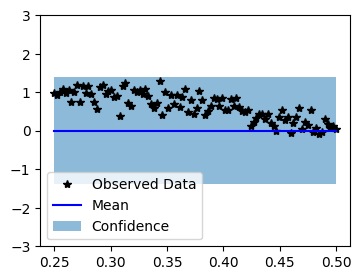

In [188]:
from matplotlib import pyplot as plt
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(4, 3))

    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()
    # Plot training data as black stars
    ax.plot(train_x.numpy(), train_y.numpy(), 'k*')
    # Plot predictive means as blue line
    ax.plot(train_x.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(train_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    ax.set_ylim([-3, 3])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])

In [189]:
training_iter = 100


# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -mll(output, train_y)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.covar_module.base_kernel.lengthscale.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

Iter 1/100 - Loss: 0.821   lengthscale: 0.693   noise: 0.693
Iter 2/100 - Loss: 0.785   lengthscale: 0.644   noise: 0.644
Iter 3/100 - Loss: 0.748   lengthscale: 0.598   noise: 0.598
Iter 4/100 - Loss: 0.711   lengthscale: 0.555   noise: 0.554
Iter 5/100 - Loss: 0.675   lengthscale: 0.514   noise: 0.513
Iter 6/100 - Loss: 0.638   lengthscale: 0.477   noise: 0.474
Iter 7/100 - Loss: 0.602   lengthscale: 0.443   noise: 0.437
Iter 8/100 - Loss: 0.565   lengthscale: 0.413   noise: 0.403
Iter 9/100 - Loss: 0.529   lengthscale: 0.387   noise: 0.370
Iter 10/100 - Loss: 0.492   lengthscale: 0.365   noise: 0.340
Iter 11/100 - Loss: 0.456   lengthscale: 0.347   noise: 0.312
Iter 12/100 - Loss: 0.419   lengthscale: 0.334   noise: 0.286
Iter 13/100 - Loss: 0.382   lengthscale: 0.325   noise: 0.262
Iter 14/100 - Loss: 0.346   lengthscale: 0.319   noise: 0.239
Iter 15/100 - Loss: 0.309   lengthscale: 0.317   noise: 0.219
Iter 16/100 - Loss: 0.273   lengthscale: 0.318   noise: 0.200
Iter 17/100 - Los

In [192]:
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    test_x = torch.linspace(0, 1.0, 51)
    observed_pred = likelihood(model(test_x))

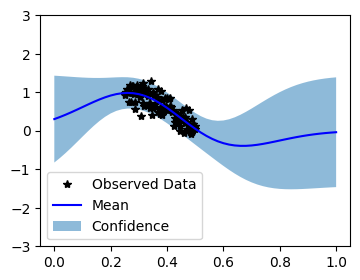

In [193]:
from matplotlib import pyplot as plt
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(4, 3))

    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()
    # Plot training data as black stars
    ax.plot(train_x.numpy(), train_y.numpy(), 'k*')
    # Plot predictive means as blue line
    ax.plot(test_x.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    ax.set_ylim([-3, 3])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])

In [ ]:
import torch
import gpytorch

class GaussianProcessModule(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


In [250]:
import torch
from torch import nn

In [298]:
class KirchhoffStressNN(torch.nn.Module):
    def __init__(self, hidden_dim, dim):
        super().__init__()
        self.a1 = nn.Sequential(
                    nn.Linear(2, hidden_dim),
                    nn.Softplus(),                     # Activation function
                    nn.Linear(hidden_dim, 1))
        self.a2 = nn.Sequential(
                    nn.Linear(2, hidden_dim),
                    nn.Softplus(),                     # Activation function
                    nn.Linear(hidden_dim, 1))
        self.g =  nn.Sequential(
                    nn.Linear(1, hidden_dim),
                    nn.Softplus(),                     # Activation function
                    nn.Linear(hidden_dim, 1))
        self.dim = dim
    def input_layer(self, deformation_gradient) :
        j = torch.det(deformation_gradient)
        F_bar = torch.pow(j, -1/3.0) * deformation_gradient
        B_bar = F_bar @ F_bar.T
        
        I1_bar = torch.trace(B_bar)
        I2_bar = 0.5 * (torch.trace(B_bar) ** 2 - torch.trace(B_bar @ B_bar))
        return (B_bar, j, I1_bar, I2_bar)
    def phi(self, T, deformation_gradient, gradu_x) :
        phi = torch.einsum('bij,bij->b', T @ torch.inverse(deformation_gradient).transpose(-1, -2), gradu_x)
        return phi
    def T1(self, B_bar) :
        return B_bar - torch.trace(B_bar)/3 * torch.eye(B_bar.shape[-1])
    def T2(self, B_bar) :
        return (torch.trace(B_bar) * torch.eye(B_bar.shape[-1]) - B_bar) - 2.0/3.0 * torch.trace(B_bar) * torch.eye(B_bar.shape[-1])
    def g_(self, j) :
        return (j - 1) * self.g(j)
    def forward(self, deformation_gradient):
        # input layer
        B_bar, j, I1_bar, I2_bar = self.input_layer(deformation_gradient)
        j = j.reshape(1,1)
        x = torch.stack([I1_bar, I2_bar], dim = -1)
        tau = self.T1(B_bar) * self.a1(x) + self.T2(B_bar) * self.a2(x) + self.g_(j) * torch.eye(self.dim)
        return tau

In [299]:
tau_model = KirchhoffStressNN(64, 2)

In [300]:
f = data["deformation_gradient"][:, [[0, 1],[2,3]]].to(dtype = torch.float32)

In [311]:
P_pred = []
for idx in range(data["deformation_gradient"].shape[0]): 
    p_pred = tau_model(f[idx]) @ torch.inverse(f[idx].T)
    P_pred.append(p_pred)
P_pred = torch.stack(P_pred)

In [314]:
qpWeight = data["qpWeight"]
gradNa = data["gradNa"]

In [326]:
f_int_nodes = torch.zeros(1441, 2, dtype = torch.float64)
for a in range(3):
	for i in range(2):
		for j in range(2):
			force = P_pred[:, i, j] * gradNa[:, a, j] * qpWeight.squeeze(-1)
			# print(force.dtype)
			f_int_nodes[:,i].index_add_(0,torch.tensor(data["cells"][:, a]), force)
    

In [327]:
boolbc = data["bc"] != 0
f_int_nodes[boolbc] = 0

In [332]:
f_int_nodes_clone = f_int_nodes.clone()
# set force on Dirichlet BC nodes to zero
f_int_nodes_clone[data["bc"] != 0] = 0
# loss for force equillibrium
eqb_loss = torch.sum(f_int_nodes_clone**2)

In [333]:
eqb_loss

tensor(0.0003, dtype=torch.float64, grad_fn=<SumBackward0>)

In [325]:
log_model_parameters(tau_model)

===== Model Parameters =====
a1.0.weight: torch.Size([64, 2]) | params=128 | requires_grad=True
a1.0.bias: torch.Size([64]) | params=64 | requires_grad=True
a1.2.weight: torch.Size([1, 64]) | params=64 | requires_grad=True
a1.2.bias: torch.Size([1]) | params=1 | requires_grad=True
a2.0.weight: torch.Size([64, 2]) | params=128 | requires_grad=True
a2.0.bias: torch.Size([64]) | params=64 | requires_grad=True
a2.2.weight: torch.Size([1, 64]) | params=64 | requires_grad=True
a2.2.bias: torch.Size([1]) | params=1 | requires_grad=True
g.0.weight: torch.Size([64, 1]) | params=64 | requires_grad=True
g.0.bias: torch.Size([64]) | params=64 | requires_grad=True
g.2.weight: torch.Size([1, 64]) | params=64 | requires_grad=True
g.2.bias: torch.Size([1]) | params=1 | requires_grad=True
Total parameters: 707
Trainable parameters: 707


In [334]:
import torch
import gpytorch

class MatrixScalingGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, matrices):
        """
        matrices: list of fixed matrices [M1, M2, M3], each torch.tensor [p,q]
        """
        super().__init__(train_x, train_y, likelihood)
        self.num_components = len(matrices)
        self.matrices = matrices  # list of fixed matrices
        
        # One GP per component
        self.means = torch.nn.ModuleList([gpytorch.means.ConstantMean() for _ in range(self.num_components)])
        self.covars = torch.nn.ModuleList([gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
                                          for _ in range(self.num_components)])
    
    def forward(self, x):
        """
        Returns a MultivariateNormal over the flattened matrix
        """
        batch_size = x.shape[0]
        total = 0
        for i in range(self.num_components):
            mean_i = self.means[i](x)  # [batch, 1]
            covar_i = self.covars[i](x)  # [batch, batch]
            
            # Scale the fixed matrix
            # Broadcast mean_i over matrix
            scaled_matrix = mean_i.view(-1, 1, 1) * self.matrices[i]  # [batch, p, q]
            
            total = total + scaled_matrix if isinstance(total, torch.Tensor) else scaled_matrix
        
        # Flatten matrix to vector for MultivariateNormal
        total_flat = total.view(batch_size, -1)  # [batch, p*q]
        return gpytorch.distributions.MultivariateNormal(total_flat, covar_i)


In [335]:
# Example fixed matrices
M1 = torch.ones(2,3)
M2 = torch.eye(2,3)
M3 = torch.arange(6).reshape(2,3).float()

matrices = [M1, M2, M3]

# Dummy training data (x) and flattened matrix outputs (y)
train_x = torch.linspace(0,1,5).reshape(-1,1)
train_y = torch.zeros(5, 2*3)  # Flattened matrix as "targets"

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = MatrixScalingGP(train_x, train_y, likelihood, matrices)


In [336]:
from gpytorch.mlls import ExactMarginalLogLikelihood

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = ExactMarginalLogLikelihood(likelihood, model)

n_iter = 200
for i in range(n_iter):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()

    if i % 20 == 0:
        print(f"Iter {i}: Loss = {loss.item():.4f}")


RuntimeError: Shape mismatch: objects cannot be broadcast to a single shape

In [337]:
output

MultivariateNormal(loc: torch.Size([5, 6]))

In [6]:
from core.datasetclass import BenchmarkDataset
import torch
import gpytorch
data_dir = "/home/mmdiscovery/shared/dataset/benchmarks/"
noise = "noise=low"
mat_model = "NeoHookean"
dataset = BenchmarkDataset(data_dir, noise, mat_model)
data = dataset[10]
piola_stress = torch.tensor(data["piola_stress"])
qpWeight = torch.tensor(data["qpWeight"])
gradNa = data["gradNa"]
print(piola_stress.shape, gradNa.shape)

torch.Size([2752, 4]) torch.Size([2752, 3, 2])


/tmp/ipykernel_43055/1480525708.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  qpWeight = torch.tensor(data["qpWeight"])


In [31]:
import torch

def J(f):
    # Determinant for each matrix in batch [N, d, d]
    return torch.det(f)  # shape [N]

def B_bar(f):
    # B_bar = J^{-2/3} * F @ F^T for each F in batch
    Jf = J(f).unsqueeze(-1).unsqueeze(-1)  # shape [N, 1, 1]
    return (Jf ** (-2.0 / 3.0)) * (f @ f.transpose(-1, -2))  # [N, d, d]

def I1_bar(f):
    B = B_bar(f)
    return B.diagonal(dim1=-2, dim2=-1).sum(-1)  # [N]

def I2_bar(f):
    B = B_bar(f)
    trB = B.diagonal(dim1=-2, dim2=-1).sum(-1)          # [N]
    trBB = (B @ B).diagonal(dim1=-2, dim2=-1).sum(-1)   # [N]
    return 0.5 * (trB ** 2 - trBB)                      # [N]

def T_func(f):
    B = B_bar(f)  # [N, d, d]
    I1 = I1_bar(f).unsqueeze(-1).unsqueeze(-1)  # [N, 1, 1]
    d = f.shape[-1]
    I = torch.eye(d, device=f.device, dtype=f.dtype).expand_as(B)  # [N, d, d]
    return (I1 / 3.0) * I - B  # [N, d, d]
def Omega_func(f):
    T = T_func(f)                          # [N, d, d]
    N, d, _ = T.shape
    I = torch.eye(d, device=f.device, dtype=f.dtype).expand(N, d, d)  # [N, d, d]
    # Flatten each matrix to vector
    T_flat = T.reshape(N, -1)  # [N, d*d]
    I_flat = I.reshape(N, -1)  # [N, d*d]
    # Stack along last axis
    Omega = torch.stack([T_flat, I_flat], dim=-1)  # [N, d*d, 2]
    return Omega
def kg_func(Omega, p, f):
    # Omega: [N, M, K]
    # p, f: [N, d, d]
    N, M, K = Omega.shape

    # Compute rhs = vec(p @ f^T)
    rhs = (p @ f.transpose(-1, -2)).reshape(N, M, 1)  # [N, M, 1]

    # Compute (ΩᵀΩ)⁻¹Ωᵀ rhs for each batch
    Omega_T = Omega.transpose(-1, -2)        # [N, K, M]
    A = Omega_T @ Omega                      # [N, K, K]
    A_inv = torch.inverse(A)                 # [N, K, K]
    pseudo = A_inv @ Omega_T                 # [N, K, M]
    kg = (pseudo @ rhs).squeeze(-1)          # [N, K]

    return kg


In [32]:
f = data["deformation_gradient"][:, [[0, 1],[2,3]]].to(dtype = torch.float32)
p = torch.tensor(data["piola_stress"][:, [[0, 1],[2,3]]]).to(dtype = torch.float32)

In [33]:
Omega = Omega_func(f)
kg = kg_func(Omega, p, f)

In [35]:
train_y = kg

In [36]:
class AffineMeanModule(gpytorch.means.Mean):
    def __init__(self, alpha_size: int, beta_size: int, s0: torch.Tensor):
        super().__init__()
        self.alpha = torch.nn.Parameter(torch.zeros(alpha_size))
        self.beta  = torch.nn.Parameter(torch.zeros(beta_size))
        self.s0 = s0

    def forward(self, s):

        return (self.alpha + self.beta.T * (s - self.s0.T)).squeeze(-1)
    
class GaussianProcessModule(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, alpha_size: int, beta_size: int, s0: torch.Tensor, dim: int):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = AffineMeanModule(alpha_size, beta_size, s0)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=dim)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [39]:
train_x_k = torch.stack([I1_bar(f), I2_bar(f)]).T
train_y_k = train_y[:, 0]
likelihood_k = gpytorch.likelihoods.GaussianLikelihood()

train_x_g = J(f) # J
train_y_g = train_y[:, 1]
likelihood_g = gpytorch.likelihoods.GaussianLikelihood()

In [40]:
train_x_k

tensor([[2.0954, 1.0957],
        [2.0962, 1.0965],
        [2.0954, 1.0957],
        ...,
        [2.0999, 1.0945],
        [2.1024, 1.0974],
        [2.1041, 1.0979]])

In [47]:
k_module = GaussianProcessModule(train_x_k, train_y_k, likelihood_k, alpha_size=1, beta_size=2, s0 = torch.tensor([3,3]).T, dim = 2)
g_module = GaussianProcessModule(train_x_g, train_y_g, likelihood_g, alpha_size=1, beta_size=1, s0 = torch.tensor([1]).T, dim = 1)

In [48]:
from gpytorch.mlls import SumMarginalLogLikelihood
model = gpytorch.models.IndependentModelList(k_module, g_module)
likelihood = gpytorch.likelihoods.LikelihoodList(k_module.likelihood, g_module.likelihood)
mll = SumMarginalLogLikelihood(likelihood, model)

In [49]:
training_iterations = 2


# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

for i in range(training_iterations):
    optimizer.zero_grad()
    output = model(*model.train_inputs)
    loss = -mll(output, model.train_targets)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iterations, loss.item()))
    optimizer.step()

RuntimeError: Shape mismatch: objects cannot be broadcast to a single shape

In [1]:
import torch
import gpytorch
import matplotlib.pyplot as plt

# 1. Choose input points
x = torch.linspace(0, 5, 100)

# 2. Define GP prior components
mean_module = gpytorch.means.ZeroMean()
kernel = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

# 3. Compute covariance matrix
mean_x = mean_module(x)
covar_x = kernel(x).evaluate()   # shape (100, 100)
covar_x += 1e-5 * torch.eye(covar_x.size(-1))

# 4. Sample from the prior
num_samples = 10000
mn = torch.distributions.MultivariateNormal(mean_x, covar_x)
samples = mn.sample((num_samples,))

# 5. Plot
# plt.figure(figsize=(8,5))
# for i in range(num_samples):
#     plt.plot(x, samples[i].detach(), lw=2, label=f'Sample {i+1}')
# plt.title('Samples from GP Prior')
# plt.xlabel('x')
# plt.ylabel('f(x)')
# # plt.legend()
# plt.show()


In [ ]:
samples.mean(dim = 0)

tensor([ 4.8431e-04,  6.8954e-04,  8.4084e-04,  1.0037e-03,  1.1108e-03,
         1.2237e-03,  1.2697e-03,  1.3247e-03,  1.2905e-03,  1.2677e-03,
         1.1972e-03,  1.0714e-03,  9.4705e-04,  7.7693e-04,  5.8876e-04,
         3.7570e-04,  1.3679e-04, -7.9376e-05, -3.3621e-04, -5.7052e-04,
        -8.2243e-04, -1.0323e-03, -1.2575e-03, -1.4181e-03, -1.5926e-03,
        -1.7372e-03, -1.8571e-03, -1.9538e-03, -2.0167e-03, -2.1107e-03,
        -2.1223e-03, -2.1330e-03, -2.1329e-03, -2.1057e-03, -2.0681e-03,
        -2.0001e-03, -1.9742e-03, -1.9217e-03, -1.8712e-03, -1.8063e-03,
        -1.7391e-03, -1.6852e-03, -1.6302e-03, -1.5791e-03, -1.5412e-03,
        -1.4895e-03, -1.4218e-03, -1.3716e-03, -1.2931e-03, -1.2270e-03,
        -1.1436e-03, -1.0342e-03, -9.4029e-04, -8.1219e-04, -6.8457e-04,
        -5.4737e-04, -3.7455e-04, -2.3641e-04, -8.1057e-05,  7.3932e-05,
         2.4953e-04,  3.3645e-04,  4.5918e-04,  5.5023e-04,  6.3021e-04,
         6.7109e-04,  6.9153e-04,  6.7533e-04,  6.5

In [56]:
mn.loc

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.])

In [43]:
train_x = torch.linspace(0, 5, 20)
train_y = torch.sin(train_x * (2 * torch.pi / 5)) + 0.2 * torch.randn(train_x.size())

In [44]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
likelihood.noise_covar.noise = 0.2 ** 2
likelihood.noise_covar.raw_noise.requires_grad_(False)
# Model
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

model = ExactGPModel(train_x, train_y, likelihood)

In [45]:
test_x = torch.linspace(0, 5, 100)

In [19]:
model.eval()
likelihood.eval()

# Get posterior predictive distribution
with torch.no_grad():
    posterior = likelihood(model(test_x))
    mean = posterior.mean
    lower, upper = posterior.confidence_region()

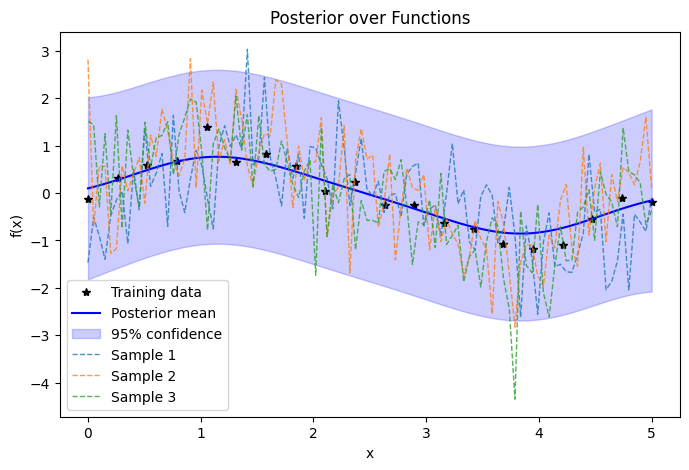

In [20]:
plt.figure(figsize=(8,5))
plt.plot(train_x, train_y, 'k*', label='Training data')
plt.plot(test_x, mean, 'b', label='Posterior mean')
plt.fill_between(test_x, lower, upper, alpha=0.2, color='blue', label='95% confidence')

# Sample a few functions from posterior
samples = posterior.sample(sample_shape=torch.Size([3]))
for i in range(3):
    plt.plot(test_x, samples[i].detach(), '--', lw=1, alpha=0.8, label=f'Sample {i+1}')

plt.legend()
plt.title('Posterior over Functions')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()


In [46]:
model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(2000):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()
    print(loss.item())

0.281252384185791
0.33018621802330017
0.19481363892555237
0.22416439652442932
0.2472303807735443
0.23593339323997498
0.2025138884782791
0.18522724509239197
0.21770063042640686
0.22037096321582794
0.19132938981056213
0.19010873138904572
0.20500078797340393
0.21070976555347443
0.20191650092601776
0.18833784759044647
0.18663692474365234
0.19773077964782715
0.19729790091514587
0.18600769340991974
0.1840745508670807
0.18996591866016388
0.1927260458469391
0.18908052146434784
0.18419083952903748
0.18522067368030548
0.18989291787147522
0.18868502974510193
0.18440309166908264
0.18454036116600037
0.18705272674560547
0.1871045082807541
0.1844981163740158
0.18314523994922638
0.18491926789283752
0.18583373725414276
0.18401989340782166
0.18326535820960999
0.18452444672584534
0.18511638045310974
0.184064581990242
0.1832931935787201
0.18403497338294983
0.18444594740867615
0.18355026841163635
0.18316717445850372
0.18373794853687286
0.1838788092136383
0.18331126868724823
0.18315330147743225
0.1836207360

In [47]:
# Switch to eval mode
model.eval()
likelihood.eval()

# Get posterior predictive distribution
with torch.no_grad():
    posterior = likelihood(model(test_x))
    mean = posterior.mean
    lower, upper = posterior.confidence_region()

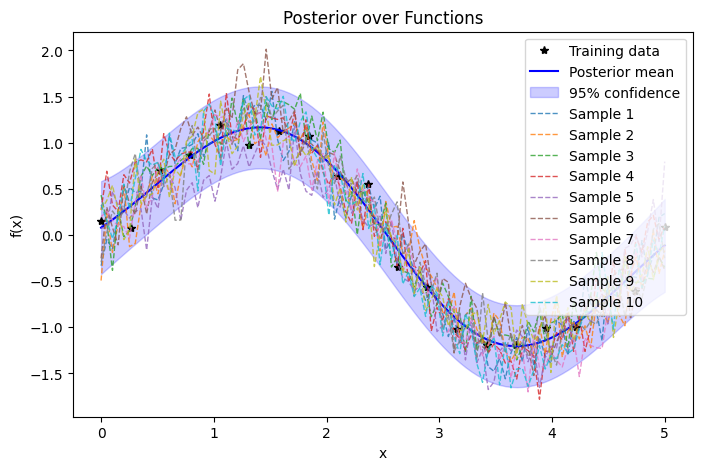

In [49]:
plt.figure(figsize=(8,5))
plt.plot(train_x, train_y, 'k*', label='Training data')
plt.plot(test_x, mean, 'b', label='Posterior mean')
plt.fill_between(test_x, lower, upper, alpha=0.2, color='blue', label='95% confidence')

# Sample a few functions from posterior
n_sample = 10
samples = posterior.sample(sample_shape=torch.Size([n_sample]))
for i in range(n_sample):
    plt.plot(test_x, samples[i].detach(), '--', lw=1, alpha=0.8, label=f'Sample {i+1}')

plt.legend()
plt.title('Posterior over Functions')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()
